# RSNA Lumbar Spine Challenge
Beginning of the notebook credits : Abhinav Suri MPH, Andrew Wentland MD PhD, Hari Trivedi MD 
– Radiology Artificial Intelligence Data Standards Committee

Author : Simon Queric

### Overview of the clinical problem

Degenerative spine conditions adversely affect people’s quality of life. Detecting these conditions is crucial for determining therapeutic plans for patients. Therefore, it is essential to develop methods for detecting and assessing the severity of degenerative spine conditions on imaging.
 
This challenge primarily focuses on identifying three types of conditions in the lumbar region of the spine (refer below for the anatomical overview). The three conditions we aim to assess are:
 
1. Foraminal narrowing (on either the left or right foramen at a specified level).
2. Subarticular stenosis (on either the left or right side at a specified level).
3. Canal stenosis (only at a specified level).
 
Each of these conditions can manifest at various levels within the spine itself, specifically at each vertebral disc (e.g., L4/5 corresponds to the vertebral disc between the L4 and L5 vertebral bodies).


For each of the conditions, you'll need to predict whether the degree of compression is normal/mild, moderate, or severe. You can refer to the example test submission `sample_submission.csv` to get a better idea for what we're looking for in terms of output. For each case, you'll have to output a score from 0 to 1 representing the probability of the patient having a specific grade (`normal_mild`, `moderate`, `severe`), at the spinal level (`l1_l2`, `l2_l3`, `l3_l4`, `l4_l5`, `l5_s1`), for that condition (`spinal_canal_stenosis`, `left_neural_foraminal_narrowing`, `right_neural_foraminal_narrowing`, `left_subarticular_stenosis`, `right_subarticular_stenosis`):


Let's talk a bit about the anatomy to get a sense for what we're asking you all to detect.

### Anatomical Overview

The spine is divided into four regions: the cervical region (with 7 vertebral bodies), the thoracic region (with 12 vertebral bodies), the lumbar region (with 5 vertebral bodies), and the sacral region (with 3-5 fused vertebral bodies). 

<img src="https://prod-images-static.radiopaedia.org/images/53655832/Gray-square.001_big_gallery.jpeg" width=400/>

*From [Radiopedia](https://prod-images-static.radiopaedia.org/images/53655832/Gray-square.001_big_gallery.jpeg)*

Between each vertebral body in all of the regions (except the sacrum) is a vertebral disc. Furthermore, along the posterior aspect of each vertebral body lies the spinal cord. At each vertebral body, spinal nerves leave the spinal cord through openings between vertebral bodies called foramina.

<img src="https://files.miamineurosciencecenter.com/media/filer_public_thumbnails/filer_public/78/1e/781e78be-8980-466f-8a82-83a5c8350770/herniated_disc_larger.jpg__720.0x600.0_q85_subject_location-360%2C300_subsampling-2.jpg" width=400/>  

*From [Miami Neuroscience Center](https://miamineurosciencecenter.com/en/conditions/herniated-disc/)*

Compression of the spinal cord or any of the nerves can cause pain to patients. Things that can cause compression of these nerves/the spinal cord include a bulging vertebral disc, degenerative changes in the bones itself (leading them to grow protrusions/become compressed), trauma, or thickening of the ligaments surrounding the spinal cord.

### Foraminal Narrowing Overview

The spinal cord has spinal nerves that exit the spinal canal through openings called foramina. The foramina are best viewed in the sagittal plane. Sometimes these openings can become compressed, resulting in foraminal narrowing. This compression results in pain for patients along the nerve distribution that is downstream of the compression. 

On the left, the image shows a sagittal MR slice where the foramina are visible. Crosshairs show where the foramina exit the spinal canal. On the right, the image shows our grading criteria for designating the degree of compression (note for this challenge, Normal/Mild is one label).
<p float="middle">
<img src="https://i.imgur.com/6c7erNM.png" width=300/>
<img src="https://i.imgur.com/b1VGiN5.png" width=300/>
</p>

### Subarticular Stenosis Overview

Subarticular stenosis is due to compression of the spinal cord in the subarticular zone (this compression can be best visualized in the axial plane).

On the left is a schematic showing the relevant anatomical zone. On the right is our grading criteria for designating the degree of subarticular stenosis (normal/mild is collapsed into one label for this challenge). 
<p float="middle">
<img src="https://files.miamineurosciencecenter.com/media/filer_public_thumbnails/filer_public/d5/08/d508ae6a-a4f2-4796-be9f-455f8df45fe1/herniation_zones.jpg__1700.0x1308.0_q85_subject_location-850%2C656_subsampling-2.jpg" width=300/>
<img src="https://i.imgur.com/Usuxgge.png" width=300/>
</p>

*Left image from [Miami Neuroscience Center](https://miamineurosciencecenter.com/en/conditions/herniated-disc/)*


### Canal Stenosis Overview

Canal stenosis is impingement on the spinal canal (where the spinal cord travels). Impingement can be due to a bulging vertebral disc, trauma, bony osteophytes (outgrowths of the vertebral bodies due to degenerative changes), or ligamental thickening (of the ligaments that run along the length of the spinal canal). The degree of compression is best assessed in the axial plane.

On the left, we show canal stenosis visible in the sagittal plane (to give an overview of what it looks like). On the right, we show our canal stenosis grading criteria (normal/mild are collapsed into one label). 

<p float="middle">
<img src="https://prod-images-static.radiopaedia.org/images/940993/f7a8adca63efae788f621869cc21e8_big_gallery.jpg" width=300/>
<img src="https://i.imgur.com/opjnAwl.png" width=300/>
</p>

*From [Radiopedia](https://prod-images-static.radiopaedia.org/images/940993/f7a8adca63efae788f621869cc21e8_big_gallery.jpg)*

### Imaging Overview

MRI imaging of the spine can be taken in three planes: the axial plane, the sagittal plane, and the coronal plane. The two main image types you'll need for this challenge are the axial and sagittal planes. The axial plane takes images horizonal slices (perpendicular to the spine) across the body from top to bottom. The sagittal plane takes vertical slices (parallel to the spine) going from left to right. 

MRI images come in multiple variants. They can generally be classified as either being T1 weighted or T2 weighted. T1 weighted images show fat as being brighter. The inner part of bones would appear brighter on T1 images. T2 images show water as brighter. The spinal canal would appear as brighter on T2 images. MRI images are not standardized with regards to the pixel values that are output from it (unlike CT images). So you'll need to figure out how to standardize these images (or maybe you wont need to at all, we'll leave it up to you). 

## Basic descriptive statistics of the dataset

In [1]:
import os
import sys
import glob
from tqdm import tqdm

import numpy as np
import pandas as pd
import nibabel as nib
import pydicom as dicom
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

sys.path.append(os.path.abspath(os.path.join("code")))
from image import Image

In [2]:
len(os.listdir("./bids-rsna-lscd"))

1975

In [3]:
np.load("exclude.npy")

FileNotFoundError: [Errno 2] No such file or directory: 'exclude.npy'

In [ ]:
descriptions = pd.read_csv("data/train_series_descriptions.csv")
train = pd.read_csv("data/train.csv")
study_ids = np.unique(descriptions["study_id"].values)
coordinates = pd.read_csv("data/train_label_coordinates.csv")

In [7]:
train

,study_id,spinal_canal_stenosis_l1_l2,spinal_canal_stenosis_l2_l3,spinal_canal_stenosis_l3_l4,spinal_canal_stenosis_l4_l5,spinal_canal_stenosis_l5_s1,left_neural_foraminal_narrowing_l1_l2,left_neural_foraminal_narrowing_l2_l3,left_neural_foraminal_narrowing_l3_l4,left_neural_foraminal_narrowing_l4_l5,...,left_subarticular_stenosis_l1_l2,left_subarticular_stenosis_l2_l3,left_subarticular_stenosis_l3_l4,left_subarticular_stenosis_l4_l5,left_subarticular_stenosis_l5_s1,right_subarticular_stenosis_l1_l2,right_subarticular_stenosis_l2_l3,right_subarticular_stenosis_l3_l4,right_subarticular_stenosis_l4_l5,right_subarticular_stenosis_l5_s1
0,4003253,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
1,4646740,Normal/Mild,Normal/Mild,Moderate,Severe,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Severe,Normal/Mild,Normal/Mild,Moderate,Moderate,Moderate,Normal/Mild
2,7143189,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
3,8785691,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
4,10728036,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1970,4282019580,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,Moderate
1971,4283570761,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
1972,4284048608,Normal/Mild,Normal/Mild,Normal/Mild,Severe,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Severe,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Severe,Normal/Mild
1973,4287160193,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,...,Normal/Mild,Severe,Moderate,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,Normal/Mild


In [8]:
descriptions.head()

,study_id,series_id,series_description
0,4003253,702807833,Sagittal T2/STIR
1,4003253,1054713880,Sagittal T1
2,4003253,2448190387,Axial T2
3,4646740,3201256954,Axial T2
4,4646740,3486248476,Sagittal T1


## Number of subjects

In [12]:
nb_subjects = len(np.unique(descriptions["study_id"].values))
print("Number of subjects : ", nb_subjects)

Number of subjects :  1975


In [13]:
nb_scan = descriptions.groupby("study_id").count().values[:,0]

In [14]:
for i in range(1, 8):
    print(f"Number of subjects with {i} sequences :", np.sum(nb_scan==i))

Number of subjects with 1 sequences : 0
Number of subjects with 2 sequences : 3
Number of subjects with 3 sequences : 1632
Number of subjects with 4 sequences : 309
Number of subjects with 5 sequences : 30
Number of subjects with 6 sequences : 1
Number of subjects with 7 sequences : 0


In [11]:
sequence_types = list(np.unique(descriptions["series_description"].values))
sequence_types

['Axial T2', 'Sagittal T1', 'Sagittal T2/STIR']

In [12]:
sequence_lists = descriptions.groupby(["study_id"]).apply(lambda x: list(zip(x['series_description']))).reset_index().values[:,1]

In [13]:
# Check if there is consistancy for subjects with 3 volumes
# i.e sequences are Axial T2, Sagittal 1, Sagittal T2/STIR

check = True
for i, seq in enumerate(sequence_lists[nb_scan==3]) : 
    seq.sort()
    # print(seq)
    if seq!=[('Axial T2',), ('Sagittal T1',), ('Sagittal T2/STIR',)] : 
        print(study_ids[i])
        check = False
print(seq)

[('Axial T2',), ('Sagittal T1',), ('Sagittal T2/STIR',)]


## Do all subjects have at least one sagittal T1?

In [14]:
# Check if every subject have Sagittal T1 volume

flag = True
count = 0
for i, study_id in enumerate(study_ids): 
    check=False
    for seq in sequence_lists[i]:
        if seq[0]=="Sagittal T1":
            check=True
            
    if not check : 
        # print(study_id)
        count+=1
        flag = False     

if count > 0 : 
    print("No.")
    print("Number of subjects without Sagittal T1 scan :", count)        

No.
Number of subjects without Sagittal T1 scan : 2


## Do all subjects have at least one Axial T2?

In [15]:
# Check if every subject have Axial T2 volume

flag = True
count = 0
for i, study_id in enumerate(study_ids): 
    check=False
    for seq in sequence_lists[i]:
        if seq[0]=="Axial T2":
            check=True
            
    if not check : 
        # print(study_id)
        count+=1
        flag = False     

if count > 0 : 
    print("No.")
    print("Number of subjects without Axial T2 scan :", count)        

In [16]:
# Check if every subject have Sagittal acquisition

flag = True
count = 0
for i, study_id in enumerate(study_ids): 
    check=False
    for seq in sequence_lists[i]:
        if "Sagittal" in seq[0]:
            check=True
            
    if not check : 
        # print(study_id)
        count+=1
        flag = False     

print("Number of subjects without Sagittal scan :", count)       

Number of subjects without Sagittal scan : 0


In [15]:
# Check if every subject have Sagittal T2 volume

flag = True
count = 0
for i, study_id in enumerate(study_ids): 
    check=False
    for seq in sequence_lists[i]:
        if seq[0]=="Sagittal T2/STIR":
            check=True
            
    if not check : 
        # print(study_id)
        count+=1
        flag = False     

print("Number of subjects without Sagittal T2/STIR scan :", count)       

Number of subjects without Sagittal T2/STIR scan : 1


### Check if there are multiple volumes

The script below writes in a dictionary the number of nifti files per subject for each sequence type.

In [16]:
X = descriptions.groupby(["series_description"]).apply(lambda x: list(zip(x['study_id'], x['series_id']))).reset_index().values

In [17]:
count = {} 
for seq in sequence_types :
    count[seq] = []

for i, seq in enumerate(sequence_types) :
    for (id, serie_id) in tqdm(X[i, 1]) :
        c = len(os.listdir(os.path.join("data", "train_nifti", str(id), str(serie_id)))) // 2
        if c > 1 :
            count[seq].append((id, serie_id, c))

100%|██████████| 1974/1974 [00:00<00:00, 66506.73it/s]


In [18]:
# check the difference between multiple niftiis for Sagittal T1

directory = "data/train_nifti/"
diff = []
for study_id, serie_id, _ in count["Sagittal T1"]:
    volumes = glob.glob(directory + str(study_id) + "/" + str(serie_id) + "/*.nii.gz")
    img1 = nib.load(volumes[0]).get_fdata()
    img2 = nib.load(volumes[1]).get_fdata()
    l2 = ((img1-img2)**2).mean()
    if l2!=0:
        diff.append((study_id, serie_id))

print(len(diff))

0


In [19]:
img1 = nib.load(volumes[0]) #.get_fdata()
img2 = nib.load(volumes[1])#.get_fdata()

In [21]:
# Check the difference between multiple niftiis for Sagittal T1

directory = "data/train_nifti/"
diff = []
for study_id, serie_id, _ in count["Sagittal T2/STIR"]:
    volumes = glob.glob(directory + str(study_id) + "/" + str(serie_id) + "/*.nii.gz")
    img1 = nib.load(volumes[0]).get_fdata()
    img2 = nib.load(volumes[1]).get_fdata()
    l2 = ((img1-img2)**2).mean()
    if l2!=0:
        diff.append((study_id, serie_id))

print(len(diff))

2


In [22]:
diff

[(723551942, 3780389705), (765688458, 2713404254)]

In [23]:
print("Number of patients with multiple volumes for sequence Sagittal T1 :", len(count["Sagittal T1"]))

Number of patients with multiple volumes for sequence Sagittal T1 : 19


In [24]:
print("Number of patients with multiple volumes for sequence Sagittal T1 :", len(count["Sagittal T2/STIR"]))

Number of patients with multiple volumes for sequence Sagittal T1 : 22


### Correlation between pathologies

In [75]:
text2int = {"Normal/Mild" : 0, "Moderate" : 1, "Severe" : 2}
labels = train.replace(text2int)
labels = labels.dropna()

In [76]:
pathologies = labels.columns[1:]
labels.head()

,study_id,spinal_canal_stenosis_l1_l2,spinal_canal_stenosis_l2_l3,spinal_canal_stenosis_l3_l4,spinal_canal_stenosis_l4_l5,spinal_canal_stenosis_l5_s1,left_neural_foraminal_narrowing_l1_l2,left_neural_foraminal_narrowing_l2_l3,left_neural_foraminal_narrowing_l3_l4,left_neural_foraminal_narrowing_l4_l5,...,left_subarticular_stenosis_l1_l2,left_subarticular_stenosis_l2_l3,left_subarticular_stenosis_l3_l4,left_subarticular_stenosis_l4_l5,left_subarticular_stenosis_l5_s1,right_subarticular_stenosis_l1_l2,right_subarticular_stenosis_l2_l3,right_subarticular_stenosis_l3_l4,right_subarticular_stenosis_l4_l5,right_subarticular_stenosis_l5_s1
0,4003253,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4646740,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,2.0,0.0,0.0,1.0,1.0,1.0,0.0
2,7143189,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,8785691,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,10728036,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [81]:
X = labels.values[:,1:]
N, P = X.shape
Xc = X - X.mean(axis=0)[None]
Xs = Xc / Xc.std(axis=0)[None]G1 = Xs.T@Xs / N
G2 = np.corrcoef(X.T)
np.sum(np.isclose(G1, G2)) == G1.shape[0]**2

True

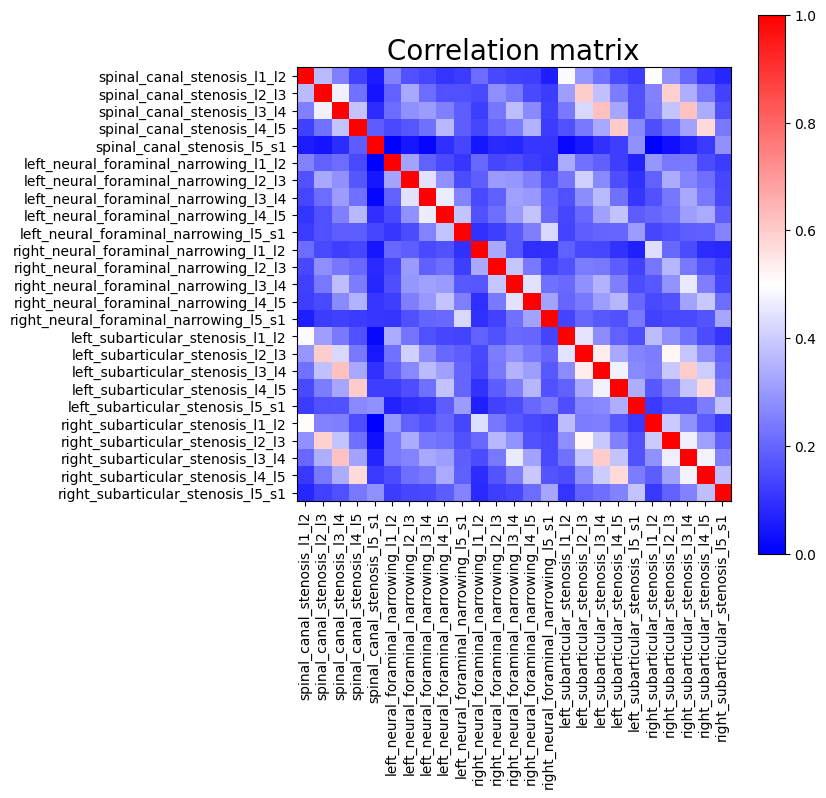

In [82]:
plt.figure(figsize=(7, 7))
plt.imshow(G1,cmap="bwr")
plt.title("Correlation matrix", fontsize=20)
plt.xticks(ticks=list(range(25)), labels=list(pathologies), rotation=90)
plt.yticks(ticks=list(range(25)), labels=list(pathologies), rotation=0)
plt.colorbar()
# plt.axis("off")
plt.show()

## Check if orientations is consistent across the nifti files

In [87]:
X = descriptions.groupby(["series_description"]).apply(lambda x: list(zip(x['study_id'], x['series_id']))).reset_index().values

sequences = {} 
for seq in sequence_types :
    sequences[seq] = []

for i, seq in enumerate(sequence_types) :
    for (id, serie_id) in tqdm(X[i, 1]) :
        c = len(os.listdir(os.path.join("data", "train_nifti", str(id), str(serie_id)))) // 2
        sequences[seq].append((id, serie_id, c))

100%|██████████| 1974/1974 [00:00<00:00, 66963.40it/s]


In [88]:
# Orientations of Sagittal T1

seq_type = "Sagittal T1"

def seq_orientations(seq_type : str = "Sagittal T1"):
    orientations = []

    for study_id, serie_id, _ in sequences[seq_type]:
        path_to_nifti = glob.glob("data/train_nifti/"+str(study_id)+"/"+str(serie_id)+"/*.nii.gz")
        try :
            path = path_to_nifti[0]
            img = Image(path)
            orientations.append(img.orientation)
        except : 
            raise ValueError(f"subject {study_id} doesn't have {seq_type} acquisition.")
    
    return orientations

In [89]:
orientations = seq_orientations("Sagittal T1")
print(np.unique(orientations))

Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to

['AIL']


In [6]:
conditions = np.unique(coordinates["condition"].values)
levels = np.unique(coordinates["level"].values)
coordinates.head()

,study_id,series_id,instance_number,condition,level,x,y
0,4003253,702807833,8,Spinal Canal Stenosis,L1/L2,322.831858,227.964602
1,4003253,702807833,8,Spinal Canal Stenosis,L2/L3,320.571429,295.714286
2,4003253,702807833,8,Spinal Canal Stenosis,L3/L4,323.030303,371.818182
3,4003253,702807833,8,Spinal Canal Stenosis,L4/L5,335.292035,427.327434
4,4003253,702807833,8,Spinal Canal Stenosis,L5/S1,353.415929,483.964602


In [8]:
# dictionary mapping a serie id to a sequence type
serie2contrast = {}
for serie_id, serie_description in descriptions[["series_id", "series_description"]].values:
    serie2contrast[serie_id] = serie_description

In [11]:
sequence_types = list(np.unique(descriptions["series_description"].values))
sequence_types
contrast2condition = {}

for contrast in sequence_types:
    contrast2condition[contrast]=[]

In [12]:
for _, serie_id, _, cond, level, _, _  in coordinates.values:
    contrast = serie2contrast[serie_id]
    contrast2condition[contrast].append(cond)

In [13]:
for contrast in sequence_types:
    print("Sequence type :", contrast)
    print("Pathology diagnosis :", list(set(contrast2condition[contrast])))

Sequence type : Axial T2
Pathology diagnosis : ['Right Subarticular Stenosis', 'Left Subarticular Stenosis']
Sequence type : Sagittal T1
Pathology diagnosis : ['Left Neural Foraminal Narrowing', 'Spinal Canal Stenosis', 'Right Neural Foraminal Narrowing']
Sequence type : Sagittal T2/STIR
Pathology diagnosis : ['Spinal Canal Stenosis']


In [15]:
contrast="Sagittal T1"
for cond in set(contrast2condition[contrast]):
    print("Count", cond, ":", contrast2condition[contrast].count(cond))

Count Left Neural Foraminal Narrowing : 9860
Count Spinal Canal Stenosis : 5
Count Right Neural Foraminal Narrowing : 9859


In [17]:
contrast="Sagittal T2/STIR"
for cond in set(contrast2condition[contrast]):
    print("Count", cond, ":", contrast2condition[contrast].count(cond))

Count Spinal Canal Stenosis : 9748


In [18]:
contrast="Axial T2"
for cond in set(contrast2condition[contrast]):
    print("Count", cond, ":", contrast2condition[contrast].count(cond))

Count Right Subarticular Stenosis : 9612
Count Left Subarticular Stenosis : 9608


### Check if pathology diagnosis is associated to one and only one contrast

Each pathology diagnosis is associated to one contrast


- ⚠️ We observed that the condition ‘neural foraminal’ is always diagnosed on the T1w contrast. Moreover:
this condition always has a right AND left,
this condition always has 5 levels
- ⚠️ We observed that the condition “spinal canal stenosis” is always diagnosed on the Sagittal T2w contrast. Moreover:
this condition always has 5 levels
- ⚠️ We observed that the condition “subarticular stenosis” is always diagnosed on the Axial T2w contrast. Moreover:
this condition always has a right AND left,
this condition always has 5 levels


In [90]:
folders = glob.glob("data/train_images/*/*")
folders.sort()
print("Number of volumes :", len(folders))

Number of volumes : 6294


In [91]:
# Check consistancy : i.e if slices are consecutive inside a folder

wrong_in = []
for folder in folders:
    _, _, study_id, serie_id = folder.split("/")
    files = os.listdir(folder)
    instance_numbers = []
    for f in files:
        k, _ = f.split(".")
        k = int(k)
        instance_numbers.append(k)
    instance_numbers.sort()
    
    count=0
    for i, k in enumerate(instance_numbers):
        
        if i>0:
            if k!=prev+1:
                count+=1
        prev = k
    
    if count>0:       
        wrong_in.append((study_id, serie_id, count))

In [92]:
wrong_in = list(set(wrong_in))

In [93]:
wrong_in = list(set(wrong_in))
wrong_in.sort()
wrong_in

[('1880970480', '1054049220', 1),
 ('208289456', '4140564625', 14),
 ('2581283971', '2683794967', 1),
 ('2620453928', '541695853', 1),
 ('2661378157', '152368824', 1),
 ('3154638975', '2052598012', 1),
 ('3324678907', '1935317419', 18),
 ('3369277408', '890756726', 26),
 ('3867046855', '3911532570', 9),
 ('723551942', '3780389705', 1),
 ('765688458', '2713404254', 1)]

In [98]:
descriptions.head()

,study_id,series_id,series_description
0,4003253,702807833,Sagittal T2/STIR
1,4003253,1054713880,Sagittal T1
2,4003253,2448190387,Axial T2
3,4646740,3201256954,Axial T2
4,4646740,3486248476,Sagittal T1


In [105]:
aberrant_instance_number = pd.DataFrame(wrong_in)
columns = {0: "study_id", 1:"series_id", 2:"change_points_count" }
aberrant_instance_number.rename(columns=columns)

,study_id,series_id,change_points_count
0,1880970480,1054049220,1
1,208289456,4140564625,14
2,2581283971,2683794967,1
3,2620453928,541695853,1
4,2661378157,152368824,1
5,3154638975,2052598012,1
6,3324678907,1935317419,18
7,3369277408,890756726,26
8,3867046855,3911532570,9
9,723551942,3780389705,1


### Check if one dicom corresponds to one slice of a volume

The scripts below check if one dicom file always correspond to a slice of one volume.

In [4]:
path="data/train_images"
# Get all dicom files in a list
files = glob.glob(path+"/*/*/*.dcm")
files.sort()

# Store the shapes of dicom into a list
shapes=[]
for f in tqdm(files):
    x = dicom.read_file(f)
    shapes.append(x.pixel_array.shape)
    
# Check if every dicom corresponds to 
x = True
for s in shapes:
    if len(s)!=2:
        x = False

print("Does each dicom correspond to a slice of one volume?")
print(f"{str(x)}")

 47%|████▋     | 69066/147218 [08:46<06:32, 199.21it/s]

# Statistics on resolutions

## Scripts below plot histograms on resolutions for each sequence type

In [4]:
def get_resolutions(seqtype):
    """
    This function returns list of resolution for a given dataset with a given sequence type.
    """
    orientation, contrast = seqtype.split("-")
    images = glob.glob("./bids-rsna-lscd/*/*/*"+orientation+"*"+contrast+"*.nii.gz")
    
    images.sort()
    
    resolutions = [] 
    study_ids = []
    for img_path in images:
        split = img_path.split("/")
        file_name = split[-1]
        sub_id = file_name.split("_")[0]
        vol = Image(img_path).change_orientation("RSP")
        resolutions.append(vol.dim)
        study_ids.append(sub_id)
    return study_ids, resolutions

In [13]:
seqtype = "sag-T1"
orientation, contrast = seqtype.split("-")

study_ids, resolutions = get_resolutions(seqtype)

Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to

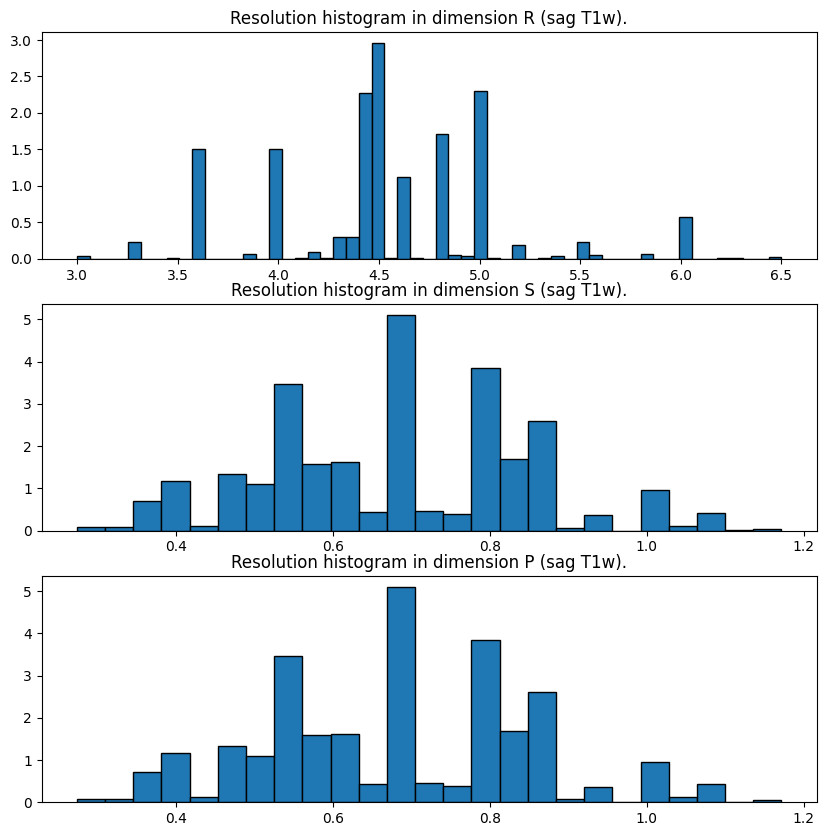

In [7]:
X = np.array(resolutions)
X[0]

z_dim = X[:,-2]
y_dim = X[:,-3]
x_dim = X[:,-4]

fig, ax = plt.subplots(nrows=3, figsize=(10, 10))
resol = [x_dim, y_dim, z_dim]
dims = ["R", "S", "P"]
for i in range(3):
    ax[i].hist(x=resol[i], bins="auto", density=True, edgecolor="k")
    ax[i].set_title(f"Resolution histogram (in mm) in dimension {dims[i]} ({orientation} {contrast}w).")
plt.show()

In [13]:
seqtype = "sag-T2"
orientation, contrast = seqtype.split("-")

study_ids, resolutions = get_resolutions(seqtype)

Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to

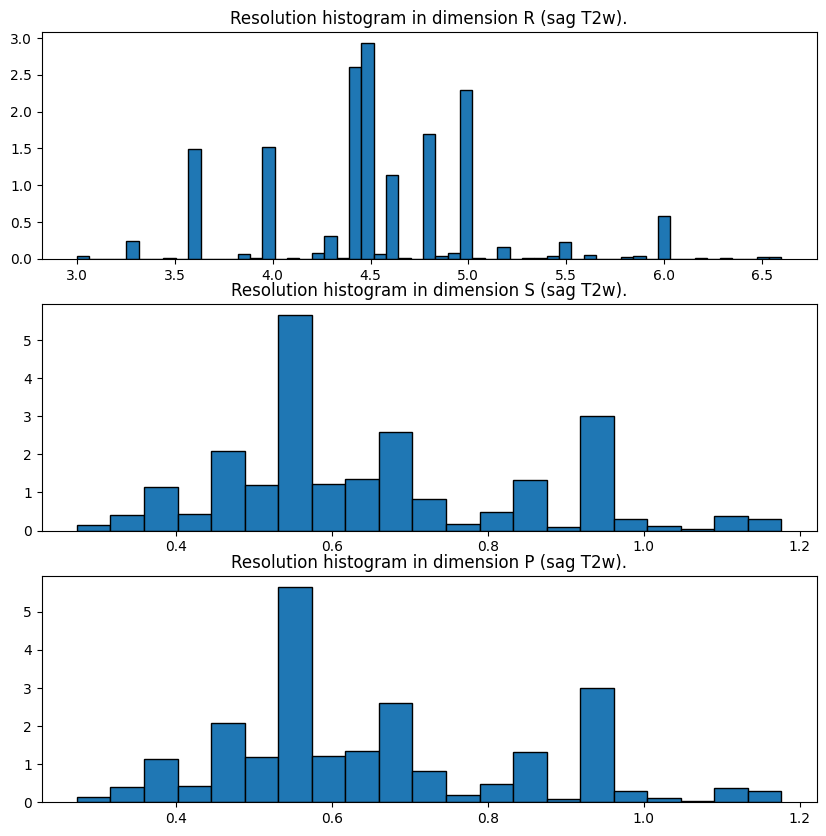

In [15]:
X = np.array(resolutions)
X[0]

z_dim = X[:,-2]
y_dim = X[:,-3]
x_dim = X[:,-4]

fig, ax = plt.subplots(nrows=3, figsize=(10, 10))
resol = [x_dim, y_dim, z_dim]
dims = ["R", "S", "P"]
for i in range(3):
    ax[i].hist(x=resol[i], bins="auto", density=True, edgecolor="k")
    ax[i].set_title(f"Resolution histogram (in mm) in dimension {dims[i]} ({orientation} {contrast}w).")
plt.show()

In [30]:
seqtype = "ax-T2"
orientation, contrast = seqtype.split("-")

study_ids, resolutions = get_resolutions(seqtype)

Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to use 'float64'.
Image header specifies datatype 'int16', but array is of type 'float64'. Header metadata will be overwritten to

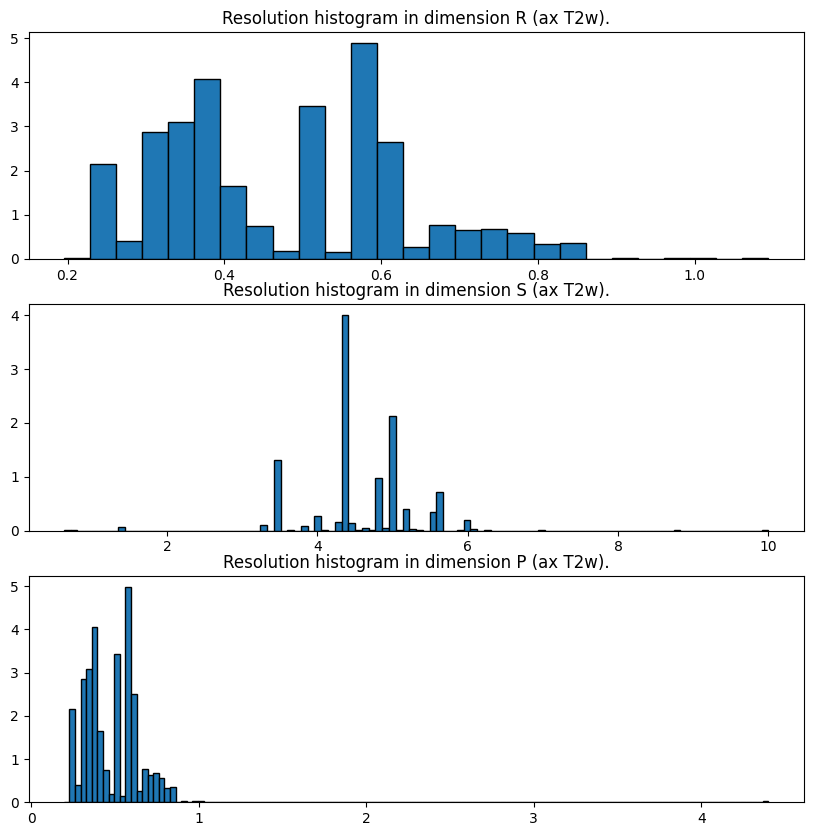

In [38]:
X = np.array(resolutions)
orientation, contrast = seqtype.split("-")

P_dim = X[:,-2]
S_dim = X[:,-3]
R_dim = X[:,-4]

fig, ax = plt.subplots(nrows=3, figsize=(10, 10))
resol = [R_dim, S_dim, P_dim]
dims = ["R", "S", "P"]
for i in range(3):
    ax[i].hist(x=resol[i], bins="auto", density=True, edgecolor="k")
    ax[i].set_title(f"Resolution histogram (in mm) in dimension {dims[i]} ({orientation} {contrast}w).")
plt.show()

In [37]:
study_ids[0]

'sub-100206310'

In [36]:
X[0]

array([320.        , 152.        , 320.        ,   1.        ,
         0.5       ,   3.49999809,   0.5       ,   1.        ])

In [40]:
np.argmax(P_dim)

1138

In [42]:
X[1138]

array([320.        , 320.        ,  48.        ,   1.        ,
         0.625     ,   0.625     ,   4.40000105,   1.        ])

In [41]:
study_ids[1138]

'sub-289846404'

In [45]:
path = "bids-rsna-lscd/sub-289846404/anat/sub-289846404_acq-ax_rec1791777852_T2w.nii.gz"
vol = Image(path).change_orientation("RSP")
print(vol.orientation)
print(vol.dim)

RSP
(320, 320, 48, 1, 0.625, 0.625, 4.400001, 1)
